In [1]:
%pip install "numpy<2"

Note: you may need to restart the kernel to use updated packages.


In [88]:
import cv2
import numpy as np

colors = {
    "mouse1": (255, 0, 255),     # magenta
    "mouse2": (0, 255, 255),     # yellow
    "mouse3": (255, 255, 0),     # cyan
}

def draw_dlc_keypoints(
    df,
    video_path,
    output_path,
    point_size=5,
    colors=None,
    likelihood_threshold=0.0,
    start_frame=0,
    end_frame=None
):
    """
    Draw DLC keypoints into a selected frame range of a video.

    Parameters
    ----------
    df : pd.DataFrame
        DeepLabCut dataframe with MultiIndex columns.

    video_path : str
        Path to input video.

    output_path : str
        Path for annotated output video.

    point_size : int
        Radius of drawn keypoints.

    colors : dict or None
        Color per individual in BGR format.

    likelihood_threshold : float
        Keypoints below this likelihood are not drawn.

    start_frame : int
        First frame to include.

    end_frame : int or None
        Last frame to include (exclusive).
        If None, video is processed until the end.
    """

    if "scorer" in df.columns.names:
        df = df.droplevel("scorer", axis=1)

    individuals = df.columns.get_level_values("individuals").unique()
    bodyparts = df.columns.get_level_values("bodyparts").unique()

    default_colors = [
        (0, 0, 255),
        (0, 255, 0),
        (255, 0, 0),
        (0, 255, 255),
        (255, 0, 255),
        (255, 255, 0),
    ]

    if colors is None:
        colors = {
            ind: default_colors[i % len(default_colors)]
            for i, ind in enumerate(individuals)
        }

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if end_frame is None:
        end_frame = min(video_frames, len(df))

    end_frame = min(end_frame, video_frames, len(df))

    if start_frame < 0 or start_frame >= end_frame:
        raise ValueError(
            f"Invalid frame range: start_frame={start_frame}, "
            f"end_frame={end_frame}"
        )

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"XVID"),
        fps,
        (width, height)
    )

    # Jump directly to selected start frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    frame_idx = start_frame

    while frame_idx < end_frame:

        ret, frame = cap.read()

        if not ret:
            break

        row = df.iloc[frame_idx]

        for ind in individuals:

            color = colors[ind]

            for bp in bodyparts:

                try:
                    x = row[(ind, bp, "x")]
                    y = row[(ind, bp, "y")]
                    likelihood = row[(ind, bp, "likelihood")]

                except KeyError:
                    continue

                if (
                    likelihood >= likelihood_threshold
                    and np.isfinite(x)
                    and np.isfinite(y)
                ):
                    cv2.circle(
                        frame,
                        (int(x), int(y)),
                        point_size,
                        color,
                        -1
                    )

        writer.write(frame)
        frame_idx += 1

    cap.release()
    writer.release()

    print(
        f"Saved frames {start_frame}–{end_frame - 1} "
        f"to: {output_path}"
    )

In [ ]:
import glob as glob
import os
import numpy as np
import pandas as pd

c:\Users\quicken\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


**STEP 1: Reading in DeepLabCut Data**

First, we have to read in the data DeepLabCut provides. This is most easily done by using the .h5 files.

In [4]:
folder = r"Z:\n2023_odor_related_behavior\other\Vorträge\261002_Coders_Club"
file = r"multi_animal_example.h5"
file_path = os.path.join(folder, file)

df = pd.read_hdf(file_path)

**There is multi-animal and single-animal deeplabcut!**

This changes the structure of the dataframe we read in.

We just read in a multi animal dataframe:

In [21]:
#df.head()
print(df.columns.nlevels)
print(df.columns.names)

4
['scorer', 'individuals', 'bodyparts', 'coords']


While a single animal dataframe is missing the "individuals" column:

In [22]:
sa_df = pd.read_hdf(r"Z:\n2023_odor_related_behavior\other\Vorträge\261002_Coders_Club\single_animal_example.h5")

print(sa_df.columns.nlevels)
print(sa_df.columns.names)

3
['scorer', 'bodyparts', 'coords']


**Multi-index information of DeepLabCut**

The Header of Deeplabcut indicates the data hierarchy and informs us about what data is stored.

In [6]:
for name in df.columns.names:
    unique_values = df.columns.get_level_values(name).unique()

    print(name, unique_values.to_list())

scorer ['DLC_HrnetW32_multi_animal_mmoNov19shuffle1_detector_best-330_snapshot_best-20']
individuals ['mouse1', 'mouse2', 'mouse3']
bodyparts ['nose', 'eye_left', 'eye_right', 'left_ear', 'right_ear', 'head_centre', 'dorsal_1', 'dorsal_2', 'dorsal_3', 'dorsal_4', 'shoulder_left', 'shoulder_right', 'lateral_left', 'lateral_right', 'hip_left', 'hip_right', 'tail_base']
coords ['x', 'y', 'likelihood']


**Slicing**

Using pandas we can *flexibly* slice our dataframe, so we can easily take only the data we are interested in.

In [7]:
scorer = df.columns.get_level_values("scorer").unique()
individuals = df.columns.get_level_values("individuals").unique()
bodyparts = df.columns.get_level_values("bodyparts").unique()
coords = df.columns.get_level_values("coords").unique()

lh_df = df.loc[:, (scorer, individuals, bodyparts, "likelihood")]
lh_df.head()

scorer      DLC_HrnetW32_multi_animal_mmoNov19shuffle1_detector_best-330_snapshot_best-20  \
individuals                                                                        mouse1   
bodyparts                                                                            nose   
coords                                                                         likelihood   
0                                                     0.571777                              
1                                                     0.593750                              
2                                                     0.788086                              
3                                                     0.800293                              
4                                                     0.810059                              

scorer                                                               \
individuals                                                           
bodyparts     eye_left  eye_right   left_ear  right_ear head_centre   
coords      likelihood likelihood likelihood likelihood  likelihood   
0             0.436035   0.418213   0.259766   0.410400    0.455811   
1             0.544922   0.843750   0.800293   0.790039    0.672852   
2             0.590820   0.958984   0.853027   0.812500    0.665527   
3             0.736816   0.915527   0.851074   0.854980    0.765625   
4             0.776855   0.748047   0.870117   0.937988    0.772461   

scorer                                                   ...             \
individuals                                              ...     mouse3   
bodyparts     dorsal_1   dorsal_2   dorsal_3   dorsal_4  ...   dorsal_2   
coords      likelihood likelihood likelihood likelihood  ... likelihood   
0             0.323486   0.076843   0.107727   0.151855  ...        NaN   
1             0.261475   0.102600   0.120117   0.174072  ...        NaN   
2             0.587891   0.089722   0.112488   0.177368  ...        NaN   
3             0.632812   0.135376   0.095337   0.171631  ...        NaN   
4             0.679199   0.757324   0.115601   0.132568  ...        NaN   

scorer                                                                       \
individuals                                                                   
bodyparts     dorsal_3   dorsal_4 shoulder_left shoulder_right lateral_left   
coords      likelihood likelihood    likelihood     likelihood   likelihood   
0                  NaN        NaN           NaN            NaN          NaN   
1                  NaN        NaN           NaN            NaN          NaN   
2                  NaN        NaN           NaN            NaN          NaN   
3                  NaN        NaN           NaN            NaN          NaN   
4                  NaN        NaN           NaN            NaN          NaN   

scorer                                                      
individuals                                                 
bodyparts   lateral_right   hip_left  hip_right  tail_base  
coords         likelihood likelihood likelihood likelihood  
0                     NaN        NaN        NaN        NaN  
1                     NaN        NaN        NaN        NaN  
2                     NaN        NaN        NaN        NaN  
3                     NaN        NaN        NaN        NaN  
4                     NaN        NaN        NaN        NaN  

[5 rows x 51 columns]

**STEP 2: Preprocessing the Data**

(array([ 2674.,  2391.,  1979.,  2742.,  4128.,  7696., 15159., 37860.,
        61414., 35011.]),
 array([0.00777435, 0.10699692, 0.20621948, 0.30544205, 0.40466461,
        0.50388718, 0.60310974, 0.70233231, 0.80155487, 0.90077744,
        1.        ]),
 <BarContainer object of 10 artists>)

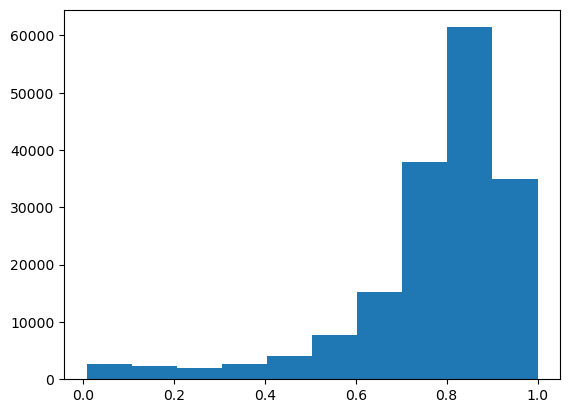

In [8]:
import matplotlib.pyplot as plt

plt.hist(lh_df.to_numpy().ravel())


**Let's check how DeepLabCut performed in labelling our mice.**

In [89]:
video = r"multi_animal_example.avi"
video_path = os.path.join(folder, video)
start_frame = 450
end_frame = 1260

draw_dlc_keypoints(
    df=df,
    video_path=video_path,
    output_path=os.path.join(folder, "video_keypoints_full.avi"),
    point_size=6,
    colors=colors,
#    start_frame=start_frame,
#    end_frame=end_frame
)


Saved frames 0–6059 to: Z:\n2023_odor_related_behavior\other\Vorträge\261002_Coders_Club\video_keypoints_full.avi


**We see some weird labels, let's check how certain the prediction is of the network.**

DeepLabCut provides for each keypoint a likelihood, how "sure" the network is about its prediction. 

Low likelihood values can indicate worse predictions, so we might want to get rid of them to increase the data quality.

Text(0, 0.5, 'frame count')

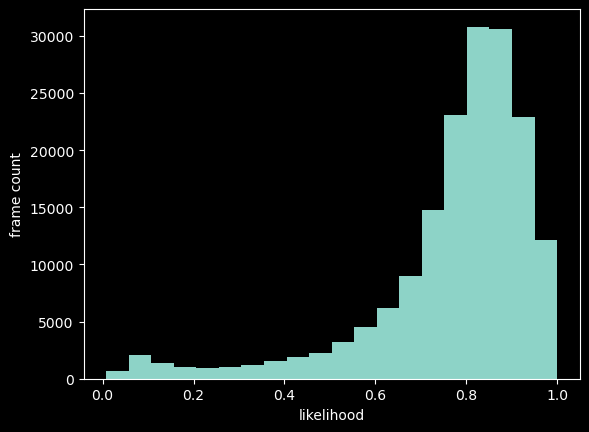

In [56]:
import matplotlib.pyplot as plt

# first put all likelihoods into a one-dimensional numpy array for better visualization
all_likelihoods = lh_df.to_numpy().ravel()
plt.style.use('dark_background')
plt.hist(all_likelihoods, bins=20) # bin size of 5%
plt.xlabel("likelihood")
plt.ylabel("frame count")

**Masking**

In pandas, we can adjust the values of our dataframe in a logical way, for example to filter bad predictions.


Let's set the filter value to 0.6, so predictions lower than 60% certainty get filtered

In [11]:
# create a copy to not alter the original df
filtered_df = df.copy()

filter_value = 0.6

# let's save how many keypoints are getting removed for our video snippet
filtered_keypoints = 0
total_keypoints = 0

# Because we have a likelihood for each bodypart of each individuum, we have to loop over the columns we want to change
for ind in individuals:
    for bp in bodyparts:
        #likelihood = df.loc[:, (scorer, ind, bp, "likelihood")]   # <-- using df.loc yields a dataframe, but for masking we need an array

        # based on our slicing, we know that 'likelihood' is one-dimensional, so we can
        # use .squeeze() to create a pandas.Series, which is similar to an array
        likelihood = df.loc[:, (scorer, ind, bp, "likelihood")].squeeze()

        # we create a mask containing True of False, depending on our filter_value for each frame
        mask = likelihood <= filter_value

        # using the mask, we can select each row that is True and update the df, so the x and y coordinates are set to "np.nan"
        filtered_df.loc[mask, (scorer, ind, bp, ["x", "y"])] = np.nan

        # update how many keypoints got filtered
        filtered_keypoints += sum(mask[start_frame:end_frame])
        total_keypoints += end_frame-start_frame

percent_filtered = filtered_keypoints/total_keypoints * 100
percent_filtered = round(percent_filtered, 2)

print(f"Filtered keypoint labels: {filtered_keypoints}\n"
      f"Total keypoints: {total_keypoints}\n"
      f"Percent filtered: {percent_filtered} %")
   

Filtered keypoint labels: 4605
Total keypoints: 41310
Percent filtered: 11.15 %


**Now we see how the video looks with the removed keypoints**

In [38]:
draw_dlc_keypoints(
    df=filtered_df,
    video_path=video_path,
    output_path=os.path.join(folder, "video_keypoints_filtered.avi"),
    point_size=6,
    colors=colors,
    start_frame=start_frame,
    end_frame=end_frame
)

Saved frames 450–1259 to: Z:\n2023_odor_related_behavior\other\Vorträge\261002_Coders_Club\video_keypoints_filtered.avi


**Using Interpolation to rescue some of the missing data**

In [ ]:
def interpolate_with_max_gap(df, max_gap=30, method="linear"):

    df = df.copy()

    interpolated_keypoints = 0

    # iterate all columns
    for col in df.columns:  

        # just work on columns that are either x or y coordinates
        if col[df.columns.names.index("coords")] not in ["x", "y"]:
            continue

        values = df[col]

        # get a series of boolean values (True = NaN)
        gaps = values.isna()

        # .shift() shifts the values down by one
        # group changes resembles where the gaps change from True to False or vice versa
        # cumsum() creates a unique group id for both valid and NaN areas
        group_changes = gaps != gaps.shift()
        group_ids = group_changes.cumsum()

        # groupby() groups the gaps by their unique group id and transform("sum") calculates the length of each gap
        # by also writing the length of the gap in each row
        gap_lengths = gaps.groupby(group_ids).transform("sum")

        interpolated = values.interpolate(
            method=method,
            limit_area="inside"
        )

        # create a mask: True when value was nan (gaps) and gap length is greater than max_gap
        too_long = gaps & (gap_lengths > max_gap)
        # .mask() replaces values in the interpolated series with NaN where the mask is True
        # .mask() is the opposite of .where() which keeps values where the mask is True
        df[col] = interpolated.mask(too_long)

        
        was_interpolated = gaps & df[col].notna()
        interpolated_keypoints += was_interpolated.iloc[start_frame:end_frame].sum()
        
    print(interpolated_keypoints)
    return df

interpolated_df = interpolate_with_max_gap(filtered_df)


<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.S

**To check the result, we again create the video but this time with the interpolated data**

In [ ]:
draw_dlc_keypoints(
    df=interpolated_df,
    video_path=video_path,
    output_path=os.path.join(folder, "video_keypoints_interpolated.avi"),
    point_size=6,
    colors=colors,
    start_frame=start_frame,
    end_frame=end_frame
)


102 coordinate columns found for interpolation.
('DLC_HrnetW32_multi_animal_mmoNov19shuffle1_detector_best-330_snapshot_best-20', 'mouse1', 'nose', 'x')


'\ndraw_dlc_keypoints(\n    df=interpolated_df,\n    video_path=video_path,\n    output_path=os.path.join(folder, "video_keypoints_interpolated.avi"),\n    point_size=6,\n    colors=colors,\n    start_frame=start_frame,\n    end_frame=end_frame\n)\n'

**STEP 3: Analyze the data**

First, we create a new Dataframe to store our analysis steps

In [ ]:
individuals_list = individuals.to_list()

metrics = ["speed", "acceleration", "center_x", "center_y", "immobile", "immobile_starts", "immobile_bouts", "dist_traveled"]

# we need at least an individual and metrics level to later sort and select the calculated metrics
# personally, I also add a name level which contains my metadata 
name = "multi_animal_example"
"""
    name = (
        f"{metadata['date']}_"                --> date of the experiment
        f"{metadata['start']}_"               --> start time of the experiment
        f"{metadata['animal_info']}_"         --> mouse ID or mouse 1, mouse n for multi animal w/o ID
        f"{metadata['experiment_info']}_"     --> stimulus information, e.g. odor, light, etc.
        f"{metadata['camera']}"               --> top1 or top2 for example
    )
"""
# build multi index columns
columns = pd.MultiIndex.from_product(
        [[name], individuals, metrics],
        names=["name", "individuals", "metrics"]
    )

metric_df = pd.DataFrame(
        index=df.index.copy(), # --> same index as the original dataframe to keep the frame numbers
        columns=columns,
        dtype=float
    )

metric_df.head()

name        multi_animal_example                                          \
individuals               mouse1                                           
metrics                    speed acceleration center_x center_y immobile   
0                            NaN          NaN      NaN      NaN      NaN   
1                            NaN          NaN      NaN      NaN      NaN   
2                            NaN          NaN      NaN      NaN      NaN   
3                            NaN          NaN      NaN      NaN      NaN   
4                            NaN          NaN      NaN      NaN      NaN   

name                                                                         \
individuals                                                                   
metrics     immobile_starts immobile_bouts dist_traveled face_investigation   
0                       NaN            NaN           NaN                NaN   
1                       NaN            NaN           NaN                NaN   
2                       NaN            NaN           NaN                NaN   
3                       NaN            NaN           NaN                NaN   
4                       NaN            NaN           NaN                NaN   

name                ...                                                  \
individuals mouse2  ...                    mouse3                         
metrics      speed  ... face_investigation  speed acceleration center_x   
0              NaN  ...                NaN    NaN          NaN      NaN   
1              NaN  ...                NaN    NaN          NaN      NaN   
2              NaN  ...                NaN    NaN          NaN      NaN   
3              NaN  ...                NaN    NaN          NaN      NaN   
4              NaN  ...                NaN    NaN          NaN      NaN   

name                                                                        \
individuals                                                                  
metrics     center_y immobile immobile_starts immobile_bouts dist_traveled   
0                NaN      NaN             NaN            NaN           NaN   
1                NaN      NaN             NaN            NaN           NaN   
2                NaN      NaN             NaN            NaN           NaN   
3                NaN      NaN             NaN            NaN           NaN   
4                NaN      NaN             NaN            NaN           NaN   

name                            
individuals                     
metrics     face_investigation  
0                          NaN  
1                          NaN  
2                          NaN  
3                          NaN  
4                          NaN  

[5 rows x 27 columns]

**Averaging all coordinates**

This allows for a more robust analysis of the speed of the animal, because individual keypoint movements and misstrackings are decreased

In [121]:
for ind in individuals:
    x_arrs = interpolated_df.loc[:, (scorer, ind, bodyparts, "x")].to_numpy()
    y_arrs = interpolated_df.loc[:, (scorer, ind, bodyparts, "y")].to_numpy()

    metric_df.loc[:, (name, ind, "center_x")] = np.nanmean(x_arrs, axis=1)
    metric_df.loc[:, (name, ind, "center_y")] = np.nanmean(y_arrs, axis=1)

C:\Users\quicken\AppData\Local\Temp\ipykernel_15996\3281718975.py:5: RuntimeWarning: Mean of empty slice
  metric_df.loc[:, (name, ind, "center_x")] = np.nanmean(x_arrs, axis=1)
C:\Users\quicken\AppData\Local\Temp\ipykernel_15996\3281718975.py:6: RuntimeWarning: Mean of empty slice
  metric_df.loc[:, (name, ind, "center_y")] = np.nanmean(y_arrs, axis=1)


Using the means, we can now plot the trajectories of each animal

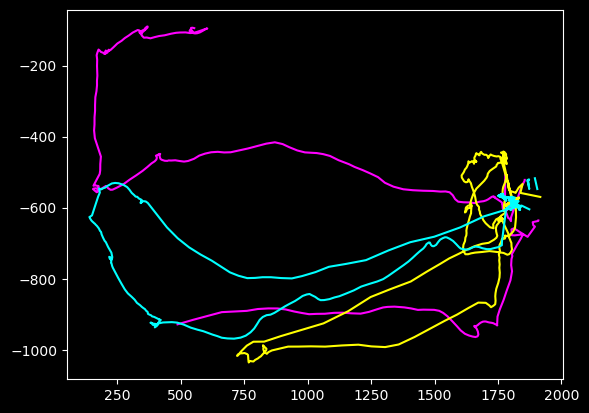

In [122]:
colors = ["magenta", "yellow", "cyan"]
plt.style.use('dark_background')
for color, ind in zip(colors, individuals):
    plt.plot(metric_df.loc[start_frame:end_frame, (name, ind, "center_x")], metric_df.loc[start_frame:end_frame, (name, ind, "center_y")]*-1, color=color)

To measure how active our mice are exploring, we can calculate the distance the animals travelled. Lets build a function for that.

In [123]:
def distance_travelled_arraybased(x_arr,y_arr):
    """
    Compute frame-to-frame Euclidean distances based on center coordinates.

    The function calculates the distance travelled between consecutive frames
    using paired x and y coordinate arrays. The output array has length
    len(x_arr) - 1, where each entry corresponds to the distance between
    frame i and i+1.

    Parameters
    ----------
    x_arr : array-like
        1D array of x-coordinates (e.g. center positions per frame).
    y_arr : array-like
        1D array of y-coordinates (same length as x_arr).

    Returns
    -------
    distance_values : np.ndarray
        1D array of Euclidean distances between consecutive frames.
    """
    distance_values = np.zeros((len(x_arr))-1)
    prev_coords = None
    for i, (x, y) in enumerate(zip(x_arr,y_arr)):
        if prev_coords:
            
            dist = _euklidean_distance(x1=x,
                                    y1=y,
                                    x2=prev_coords[0],
                                    y2=prev_coords[1]
                                    )
            # falls dist values einen unlogischen Schwellenwert überschreiten, wird der letzte gültige Wert genommen
            # falls es noch keine vorherigen Werte gibt, wird 0 eingesetzt
            if i > 2 and dist > 200:
                dist = distance_values[i-2]
            elif dist > 200:
                dist = 0
            
            distance_values[i-1] = dist
            
                
        prev_coords = (x,y)    

    return distance_values

def _euklidean_distance(x1, y1, x2, y2):
        """
        This func returns the euklidean distance between two points.
        (x1, y1) and (x2, y2) are the cartesian coordinates of the points.
        """
        if np.isnan(x1):
            distance = np.nan
        elif np.isnan(x2):
            distance = np.nan
        else:
            distance = np.sqrt((x2-x1)**2 + (y2-y1)**2)

        return distance

Let's now apply the function and store the data with the previously calculated mouse center coordinates.

In [124]:
for ind in individuals:
    x_coords = metric_df.loc[:, (name, ind, "center_x")]
    y_coords = metric_df.loc[:, (name, ind, "center_y")]
    speed = distance_travelled_arraybased(x_coords, y_coords) # --> speed in pixels per frame

    metric_df.loc[1:, (name, ind, "speed")] = speed

Let's check the animals speed for the duration of the video we looked at. 

Text(0, 0.5, 'speed [pixels/frame]')

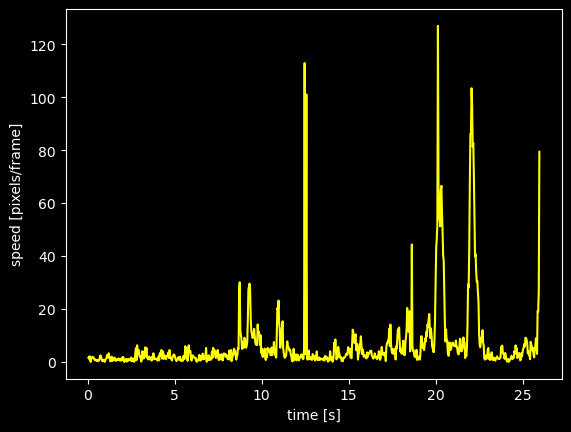

In [125]:

speed = metric_df.loc[start_frame+1:end_frame, (name, "mouse2", "speed")]

time = (speed.index - start_frame) / 30
plt.style.use('dark_background')
plt.plot(time, speed, color="yellow", label=ind)
plt.xlabel("time [s]")
plt.ylabel("speed [pixels/frame]")

# lets investigate the immobile behavior more closely
#plt.ylim(0, 10)


Even though the mouse is sitting still in the first seconds, we have movement here. Lets try a moving average to reduce the effect of the baseline movement of the center coordinate.

Text(0, 0.5, 'speed [pixels/frame]')

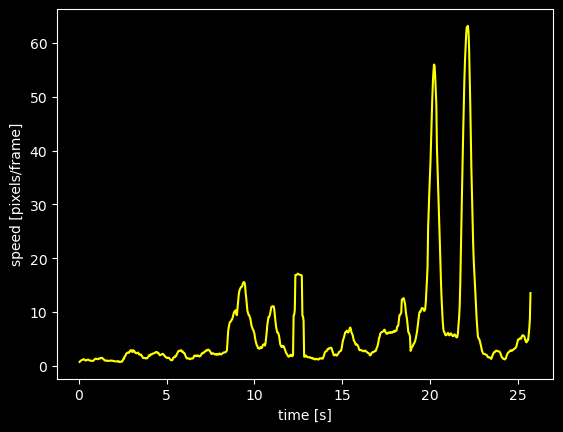

In [126]:
speed = metric_df.loc[start_frame+1:end_frame, (name, "mouse2", "speed")]

window = 15

kernel = np.ones(window) / window
speed_smooth = np.convolve(speed, kernel, mode='same')

time = (speed.index - start_frame) / 30
plt.style.use('dark_background')
plt.plot(time, speed_smooth, color="yellow", label=ind)
plt.xlabel("time [s]")
plt.ylabel("speed [pixels/frame]")

# lets investigate the immobile behavior more closely
#plt.ylim(0, 20)

To go even further, lets try to curate the speed even more, by getting rid of the "immobile jitter"

Text(0, 0.5, 'speed [pixels/frame]')

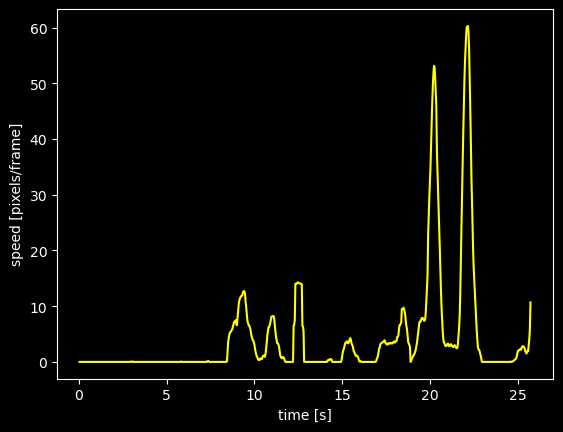

In [127]:
curated_speed = np.zeros(len(speed_smooth))
thrsh = np.nanmedian(speed_smooth)
for i, val in enumerate(speed_smooth):
    if val > thrsh:
        curated_speed[i] = val - thrsh
    elif np.isnan(val):
            curated_speed[i] = np.nan


plt.plot(time, curated_speed, color="yellow", label=ind)
plt.xlabel("time [s]")
plt.ylabel("speed [pixels/frame]")

# lets investigate the immobile behavior more closely
#plt.ylim(0, 20)


**Calculating the derivation of our speed let's us analyse speed events**

Text(0, 0.5, 'acceleration [pixels/frame²]')

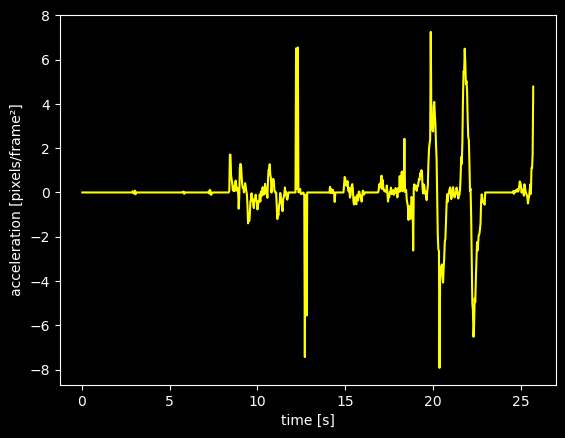

In [128]:
a = np.diff(curated_speed)

plt.plot(time[:-1], a, color="yellow", label=ind)
plt.xlabel("time [s]")
plt.ylabel("acceleration [pixels/frame²]")

**Using the curated speed, we can calculate the time animals were immobile and the distance they travelled.**

Let's first update our metric dataframe

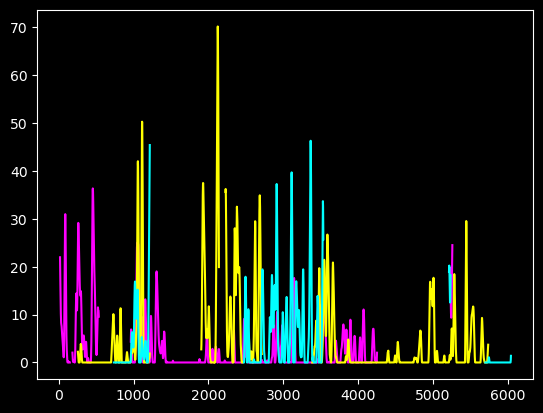

In [133]:
for ind in individuals:
    speed = metric_df.loc[:, (name, ind, "speed")]
    kernel = np.ones(window) / window
    speed_smooth = np.convolve(speed, kernel, mode='same')
    curated_speed = np.zeros(len(speed_smooth))
    thrsh = np.nanmedian(speed_smooth)
    for i, val in enumerate(speed_smooth):
        if val > thrsh:
            curated_speed[i] = val - thrsh
        elif np.isnan(val):
                curated_speed[i] = np.nan

    metric_df.loc[:, (name, ind, "speed")] = curated_speed

    plt.plot(curated_speed, color=colors[individuals_list.index(ind)], label=ind)

    

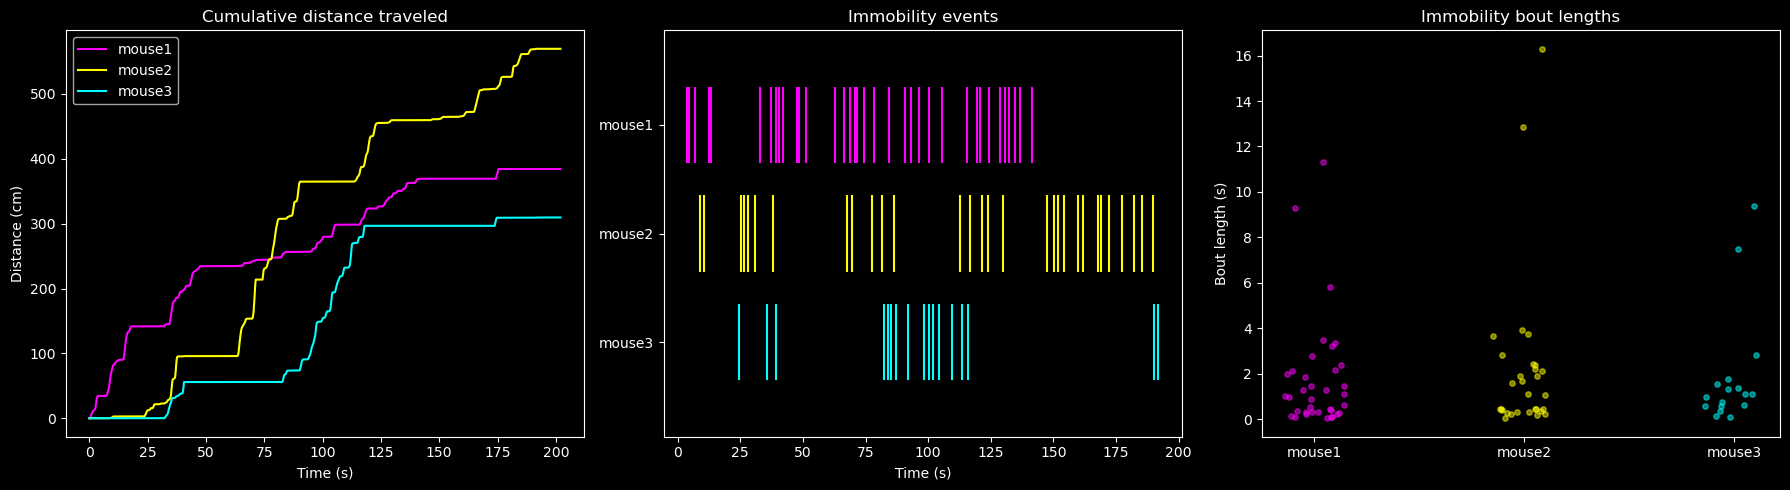

In [134]:
fps = 30

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rng = np.random.default_rng(42)

for i, (ind, color) in enumerate(zip(individuals, colors)):

    speed = metric_df.loc[:, (name, ind, "speed")].to_numpy()

    # Identify immobility events
    immobile = (speed == 0).astype(int)

    immobile_diff = np.diff(immobile, prepend=0, append=0)
    immobile_starts = np.where(immobile_diff == 1)[0]
    immobile_ends = np.where(immobile_diff == -1)[0]
    immobile_bouts = immobile_ends - immobile_starts

    # Calculate cumulative distance
    dist_traveled = np.nancumsum(speed / fps)

    # Save metrics
    metric_df.loc[:, (name, ind, "immobile")] = immobile
    metric_df.loc[:len(immobile_starts)-1, (name, ind, "immobile_starts")] = immobile_starts
    metric_df.loc[:len(immobile_bouts)-1, (name, ind, "immobile_bouts")] = immobile_bouts
    metric_df.loc[:, (name, ind, "dist_traveled")] = dist_traveled

    # 1. Cumulative distance traveled
    time = np.arange(len(speed)) / fps
    axes[0].plot(time, dist_traveled, color=color, label=ind)

    # 2. Immobility eventplot
    axes[1].eventplot(
        immobile_starts / fps,
        lineoffsets=i,
        linelengths=0.7,
        colors=color
    )

    # 3. Immobility bout lengths scatter
    jitter = rng.uniform(-0.15, 0.15, size=len(immobile_bouts))

    axes[2].scatter(
        np.full(len(immobile_bouts), i) + jitter,
        immobile_bouts / fps,
        color=color,
        alpha=0.5,
        s=15
    )

# Plot 1
axes[0].set(
    title="Cumulative distance traveled",
    xlabel="Time (s)",
    ylabel="Distance (cm)"
)
axes[0].legend()

# Plot 2
axes[1].set(
    title="Immobility events",
    xlabel="Time (s)",
    yticks=range(len(individuals)),
    yticklabels=individuals
)
axes[1].invert_yaxis()

# Plot 3
axes[2].set(
    title="Immobility bout lengths",
    ylabel="Bout length (s)",
    xticks=range(len(individuals)),
    xticklabels=individuals
)

plt.tight_layout()
plt.show()


In [135]:
metric_df.to_csv(os.path.join(folder, "metric_df.csv"), index=False)